<a href="https://colab.research.google.com/github/Dhairy006/Fabric-Defect-Detection/blob/main/WinterProject_FabricDefect_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imports
import os,cv2,numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet  import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [ ]:
# Global Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
RANDOM_STATE = 42

In [ ]:
#Dataset Download
DATASET_ROOT = kagglehub.dataset_download(
    "ziya07/multi-class-fabric-defect-detection-dataset"
)

DATASET_PATH = os.path.join(DATASET_ROOT, "Dataset")

print("Dataset path:", DATASET_PATH)
print("Classes found:", os.listdir(DATASET_PATH))

Using Colab cache for faster access to the 'multi-class-fabric-defect-detection-dataset' dataset.
Dataset path: /kaggle/input/multi-class-fabric-defect-detection-dataset/Dataset
Classes found: ['Pinched fabric', 'Vertical', 'Needle mark', 'defect free', 'Broken stitch', 'horizontal', 'hole', 'lines', 'stain']


In [ ]:
# Class Mapping
CLASS_NAMES = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES = len(CLASS_NAMES)

CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}

print(CLASS_TO_IDX)

{'Broken stitch': 0, 'Needle mark': 1, 'Pinched fabric': 2, 'Vertical': 3, 'defect free': 4, 'hole': 5, 'horizontal': 6, 'lines': 7, 'stain': 8}


In [ ]:
# Data Indexing
image_paths = []
labels = []

for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img_name))
        labels.append(CLASS_TO_IDX[cls])

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))

Total images: 3067


In [ ]:
# Train/Validation/Test Split
train_paths, temp_paths, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=RANDOM_STATE
)

val_paths, test_paths, y_val, y_test = train_test_split(
    temp_paths,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Train: 2146 | Val: 460 | Test: 461


In [ ]:
# Image Loader
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = preprocess_input(img.astype(np.float32))
    return img

In [ ]:
# ===============================
# Load image for visualization ONLY
# ===============================
def load_original_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [ ]:
# ===============================
# OpenCV Texture-Based Defect Localization
# ===============================
from skimage.feature import local_binary_pattern


In [ ]:
# Load Datasets
X_train = np.array([load_image(p) for p in train_paths])
X_val   = np.array([load_image(p) for p in val_paths])
X_test  = np.array([load_image(p) for p in test_paths])

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val, NUM_CLASSES)
y_test_cat  = to_categorical(y_test, NUM_CLASSES)

print(X_train.shape, X_val.shape, X_test.shape)

(2146, 224, 224, 3) (460, 224, 224, 3) (461, 224, 224, 3)


In [ ]:
# Class Weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(3.056980056980057), 1: np.float64(3.1792592592592595), 2: np.float64(3.1374269005847952), 3: np.float64(3.3583724569640063), 4: np.float64(0.2044978082713932), 5: np.float64(1.2103778905809364), 6: np.float64(2.5099415204678364), 7: np.float64(2.1676767676767676), 8: np.float64(0.8577138289368506)}


In [ ]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(
    X_train, y_train_cat, batch_size=BATCH_SIZE
)

val_generator = val_datagen.flow(
    X_val, y_val_cat, batch_size=BATCH_SIZE, shuffle=False
)

In [ ]:
# Model Definition
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Phase-1 training

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [ ]:
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,379,820 (16.71 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Training
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 70s 672ms/step - accuracy: 0.6855 - loss: 1.1646 - val_accuracy: 0.8957 - val_loss: 0.3242 - learning_rate: 0.0010
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 339ms/step - accuracy: 0.8723 - loss: 0.5033 - val_accuracy: 0.8913 - val_loss: 0.3449 - learning_rate: 0.0010
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 332ms/step - accuracy: 0.9015 - loss: 0.3916 - val_accuracy: 0.9065 - val_loss: 0.2240 - learning_rate: 0.0010
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 344ms/step - accuracy: 0.9153 - loss: 0.3540 - val_accuracy: 0.8783 - val_loss: 0.3365 - learning_rate: 0.0010
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 353ms/step - accuracy: 0.9162 - loss: 0.3006 - val_accuracy: 0.9065 - val_loss: 0.2522 - learning_rate: 0.0010
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 347ms/step - accuracy: 0.9204 - loss: 0.3116 - val_accuracy: 0.9196 - val_loss: 0.2093 - learning_rate: 0.0010
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 345ms/step - accuracy: 0.9227 - loss: 0.

In [ ]:
# Test Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

Test Accuracy: 0.9436
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 488ms/step
                precision    recall  f1-score   support

 Broken stitch     1.0000    0.6471    0.7857        17
   Needle mark     0.7273    1.0000    0.8421        16
Pinched fabric     1.0000    1.0000    1.0000        16
      Vertical     0.8333    1.0000    0.9091        15
   defect free     0.9919    0.9800    0.9859       250
          hole     0.8718    0.8095    0.8395        42
    horizontal     0.9524    0.9524    0.9524        21
         lines     0.8261    0.7917    0.8085        24
         stain     0.9219    0.9833    0.9516        60

      accuracy                         0.9436       461
     macro avg     0.9027    0.9071    0.8972       461
  weighted avg     0.9476    0.9436    0.9430       461



<Figure size 1000x1000 with 0 Axes>

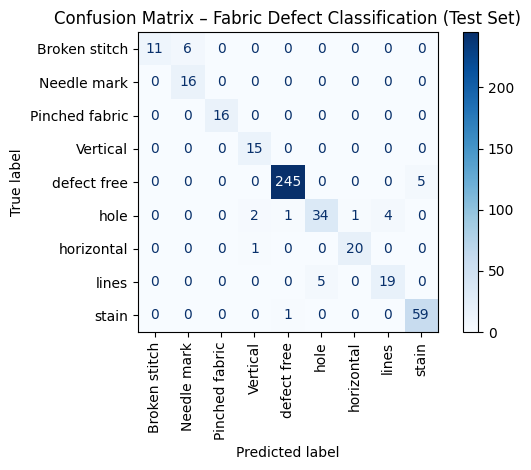

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

plt.figure(figsize=(10, 10))
disp.plot(
    cmap="Blues",
    xticks_rotation="vertical",
    values_format="d"
)
plt.title("Confusion Matrix – Fabric Defect Classification (Test Set)")
plt.tight_layout()
plt.show()


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_activation"):
    #Create a model that maps the input image to the activations of the last conv layer
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    #Compute gradients for the top predicted class
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    #Get the gradient of the class with regard to the output feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    #Multiply each channel by "how important this channel is"
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    #Normalize heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def get_opencv_bbox(heatmap, threshold_val=0.5):
    #Resize to match image size
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    #Convert to binary mask using OpenCV
    mask = (heatmap_resized > threshold_val).astype(np.uint8) * 255
    #Find contours of the defect
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_cnt = max(contours, key=cv2.contourArea)
        return cv2.boundingRect(largest_cnt)
    return None

def predict_and_plot_results(img_path, model, CLASS_NAMES):
    #Prepare image for model prediction
    img = load_image(img_path)
    img_tensor = np.expand_dims(img, axis=0)

    #Get Prediction
    preds = model.predict(img_tensor, verbose=0)
    idx = np.argmax(preds[0])
    label = CLASS_NAMES[idx]
    confidence = preds[0][idx]

    #Prepare image for OpenCV drawing (BGR to RGB for display)
    display_img = cv2.imread(img_path)
    display_img = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    display_img = cv2.resize(display_img, (224, 224))

    #Only draw boundary if a defect is detected
    if label != 'defect free':
        # 'top_activation' is the correct layer for your EfficientNetB0 model
        heatmap = make_gradcam_heatmap(img_tensor, model, "top_activation")
        bbox = get_opencv_bbox(heatmap)

        if bbox:
            x, y, w, h = bbox
            cv2.rectangle(display_img, (x, y), (x + w, y + h), (255, 0, 0), 2)

                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    plt.imshow(display_img)
    plt.title(f"Prediction: {label}")
    plt.axis('off')

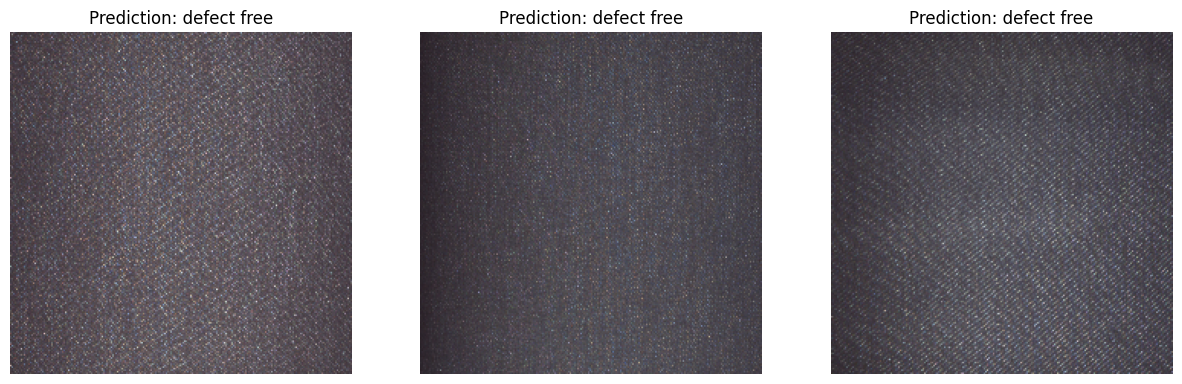

In [ ]:
import random
test_samples = random.sample(list(val_paths), 3)

plt.figure(figsize=(15, 5))
for i, path in enumerate(test_samples):
    plt.subplot(1, 3, i+1)
    predict_and_plot_results(path, model, CLASS_NAMES)
plt.show()